# Simulated dark matter search with Gammapy

This notebook presents a toy example of an indirect dark matter search using Gammapy.

The goal is to build a simplified sensitivity workflow for a dark matter annihilation signal observed with CTAO instrument response functions. We simulate a background-only dataset, fit background-only and background-plus-signal hypotheses, and derive an approximate upper limit on the annihilation cross section.

This is a pedagogical example showing the main ingredients of a gamma-ray dark matter analysis:

- a dark matter annihilation spectrum;
- a J-factor spatial template;
- a simulated 3D `MapDataset`;
- background-only and signal-plus-background likelihood fits;
- a profile-likelihood upper limit on the signal normalization.

In [1]:
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from regions import CircleSkyRegion
from scipy.interpolate import interp1d
from scipy.optimize import brentq

import gammapy
from gammapy.astro.darkmatter import (
    DarkMatterAnnihilationSpectralModel,
    JFactory,
    PrimaryFlux,
    profiles,
)
from gammapy.data import Observation
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.maps import MapAxis, WcsGeom, WcsNDMap
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    TemplateSpatialModel,
)

print(f"Gammapy version: {gammapy.__version__}")

Gammapy version: 1.3


## Analysis setup

We start by defining the basic ingredients of the simulated analysis.

In this notebook, we use one illustrative dark matter mass and annihilation channel. We also define a CTAO-like observation setup, a pointing direction near the Galactic Center, and the reconstructed and true energy axes used to build the 3D `MapDataset`.

The reconstructed-energy axis defines the energy bins of the final counts cube. The true-energy axis is used internally for model prediction and IRF convolution.

In [2]:
# Dark matter parameters
mchi = 1.0 * u.TeV
channel_b = "b"

# Observation setup
livetime = 50.0 * u.h
frame = "galactic"

target_position = SkyCoord(
    l=0.0 * u.deg,
    b=0.0 * u.deg,
    frame=frame,
)

# Reconstructed-energy axis
energy_axis = MapAxis.from_energy_bounds(
    20 * u.GeV,
    50 * u.TeV,
    nbin=30,
    name="energy",
)

# True-energy axis used for IRF convolution and model prediction
energy_axis_true = MapAxis.from_energy_bounds(
    10 * u.GeV,
    100 * u.TeV,
    nbin=40,
    name="energy_true",
)

# Spatial geometry for the 3D analysis
geom = WcsGeom.create(
    skydir=target_position,
    binsz=0.05,
    width=(10, 10),
    frame=frame,
    axes=[energy_axis],
)

# CTAO Prod5 IRF file
IRF_PATH = "$GAMMAPY_DATA/cta-caldb/Prod5-South-20deg-AverageAz-14MSTs37SSTs.180000s-v0.1.fits"

print(f"DM mass: {mchi}")
print(f"Annihilation channel: {channel_b}")
print(f"Livetime: {livetime}")
print(f"Pointing direction: {target_position}")

DM mass: 1.0 TeV
Annihilation channel: b
Livetime: 50.0 h
Pointing direction: <SkyCoord (Galactic): (l, b) in deg
    (0., 0.)>


## Dark matter spectra at production

Before building the simulated observation, we inspect the gamma-ray spectra produced by different dark matter annihilation channels.

Gammapy provides tabulated prompt spectra through `PrimaryFlux`, based on PPPC 4 DM ID tables. These spectra give the number of photons produced per annihilation as a function of energy, before multiplying by the astrophysical J-factor and the annihilation cross section.

This plot is only a diagnostic illustration. The actual benchmark analysis below uses the mass and channel defined in the setup section.

In [3]:
# Inspect the list of available annihilation channels
primary_flux = PrimaryFlux(mDM=mchi, channel=channel_b)
print(primary_flux.allowed_channels)

['eL', 'eR', 'e', 'muL', 'muR', 'mu', 'tauL', 'tauR', 'tau', 'q', 'c', 'b', 't', 'WL', 'WT', 'W', 'ZL', 'ZT', 'Z', 'g', 'gamma', 'h', 'nu_e', 'nu_mu', 'nu_tau', 'V->e', 'V->mu', 'V->tau']


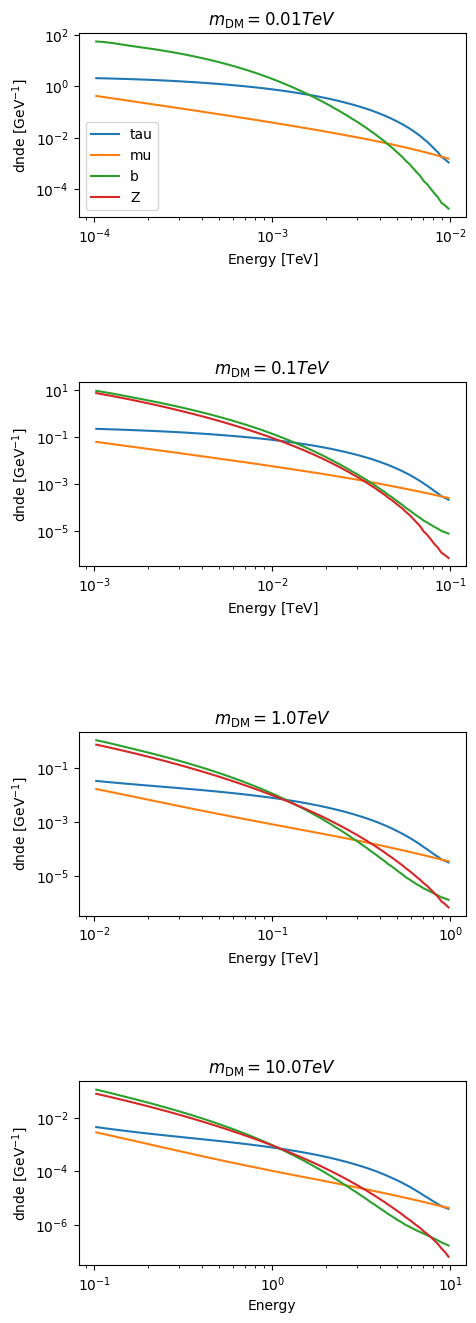

In [4]:
# Compare example prompt spectra for different masses and channels
masses = [0.01, 0.1, 1, 10] * u.TeV
channels_to_plot = ["tau", "mu", "b", "Z"]

fig, axes = plt.subplots(4, 1, figsize=(5, 16))

for mass, ax in zip(masses, axes):
    ax.set_title(rf"$m_\mathrm{{DM}} = {mass}$")
    ax.set_yscale("log")
    ax.set_ylabel(r"$dN/dE$")

    for plot_channel in channels_to_plot:
        primary_flux = PrimaryFlux(mDM=mass, channel=plot_channel)
        primary_flux.plot(
            energy_bounds=[mass / 100, mass],
            ax=ax,
            label=plot_channel,
            yunits=u.Unit("1 / GeV"),
        )

axes[-1].set_xlabel("Energy")
axes[0].legend()
plt.subplots_adjust(hspace=0.9)
plt.show()

## J-factor spatial template

The astrophysical part of a dark matter annihilation signal is encoded in the J-factor, defined as the line-of-sight integral of the squared dark matter density.

Here we build a simple J-factor map toward the Galactic Center using an Einasto density profile. The profile is normalized to the local dark matter density, and the J-factor is computed on a 2D WCS geometry matching the spatial part of the analysis.

This map will later be used as the spatial template for the dark matter signal model.

In [ ]:
# Define and normalize an Einasto dark matter density profile
profile = profiles.EinastoProfile(r_s=28.44 * u.kpc)

profiles.DMProfile.DISTANCE_GC = 8.33 * u.kpc
profiles.DMProfile.LOCAL_DENSITY = 0.39 * u.Unit("GeV / cm3")

profile.scale_to_local_density()

# Use the spatial part of the analysis geometry for the J-factor map
geom_j = geom.to_image()

# Compute the J-factor map
jfactory = JFactory(
    geom=geom_j,
    profile=profile,
    distance=profiles.DMProfile.DISTANCE_GC,
)

jfactor = jfactory.compute_jfactor()
jmap = WcsNDMap(geom=geom_j, data=jfactor.value, unit=jfactor.unit)

# Define an illustrative circular region for an integrated J-factor
roi_region = CircleSkyRegion(
    center=target_position,
    radius=1.5 * u.deg,
)

roi_pixel_region = roi_region.to_pixel(wcs=geom_j.wcs)
JFAC = roi_pixel_region.to_mask().multiply(jfactor).sum()

print(f"Integrated J-factor in the ROI: {JFAC:.3e}")

We can visualize the resulting J-factor map and overlay the region used to compute the integrated J-factor.

The map is strongly peaked toward the Galactic Center because the annihilation signal scales as the square of the dark matter density.

In [ ]:
fig = plt.figure(figsize=(6, 5))

ax = jmap.plot(
    cmap="viridis",
    norm=LogNorm(),
    add_cbar=True,
)

roi_pixel_region.plot(
    ax=ax,
    facecolor="none",
    edgecolor="white",
    lw=1.5,
)

ax.set_title(f"J-factor map [{jmap.unit}]")
plt.show()

## Expected integrated flux template

The J-factor map contains only the astrophysical part of the annihilation signal. To obtain an expected gamma-ray flux template, we combine it with the dark matter annihilation spectrum integrated over an energy range.

This flux map is only used as a diagnostic visualization. The likelihood analysis below will use a spectral model and the J-factor template directly.

In [ ]:
# Energy-integrated dark matter spectral factor for the benchmark model
dm_spectrum_for_flux = DarkMatterAnnihilationSpectralModel(
    mass=mchi,
    channel=channel_b,
)

integrated_spectral_factor = dm_spectrum_for_flux.integral(
    energy_min=0.1 * u.TeV,
    energy_max=10.0 * u.TeV,
)

integrated_flux = (jfactor * integrated_spectral_factor).to("cm-2 s-1")

flux_map = WcsNDMap(
    geom=geom_j,
    data=integrated_flux.value,
    unit=integrated_flux.unit,
)

fig = plt.figure(figsize=(6, 5))

ax = flux_map.plot(
    cmap="viridis",
    norm=LogNorm(),
    add_cbar=True,
)

roi_pixel_region.plot(
    ax=ax,
    facecolor="none",
    edgecolor="white",
    lw=1.5,
)

ax.set_title(
    f"Integrated flux template [{flux_map.unit}]\n"
    f"mDM = {mchi.to('TeV')}, channel = {channel_b}"
)

plt.show()

## Simulated CTAO-like dataset

We now build a simulated 3D `MapDataset` using CTAO public instrument response functions (IRFs).

The dataset contains the main IRF-projected quantities needed for a binned likelihood analysis:

- exposure;
- background;
- point-spread function;
- energy dispersion;
- safe energy mask.

At this stage, the dataset does not yet contain simulated counts. Counts will be generated later under the background-only hypothesis.

In [ ]:
# Load CTAO Prod5 IRFs
irfs = load_irf_dict_from_file(IRF_PATH)

# Create a synthetic observation with the chosen livetime and pointing direction
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Pointing will be required to be provided as FixedPointingInfo",
    )

    observation = Observation.create(
        pointing=target_position,
        livetime=livetime,
        irfs=irfs,
    )

# Create an empty dataset on the analysis geometry
empty_dataset = MapDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true,
    name="dataset-simu",
)

# Fill the dataset with IRF-projected quantities
maker = MapDatasetMaker(
    selection=["exposure", "background", "psf", "edisp"],
)

safe_mask_maker = SafeMaskMaker(
    methods=["bkg-peak"],
)

dataset = maker.run(empty_dataset, observation)
dataset = safe_mask_maker.run(dataset, observation)

dataset

## Dataset overview

The `peek()` method provides a compact visual summary of the simulated dataset.

At this point, the counts map is still empty because we have not generated fake events yet. The exposure, background, energy dispersion, PSF, and safe mask have already been computed from the IRFs.

In [ ]:
# Inspect the simulated dataset before generating counts
dataset.peek();

## Signal and background models

We now define the models used in the simulated likelihood analysis.

The dark matter signal model has two components:

- a spectral model, given by the prompt annihilation spectrum for the chosen mass and channel;
- a spatial model, given by the J-factor map used as a template morphology.

The spectral model includes the integrated J-factor `JFAC`. The spatial template is therefore used to describe how the signal is distributed across the sky, while the total normalization is controlled by the spectral model.

The `scale` parameter multiplies the reference annihilation cross section used by `DarkMatterAnnihilationSpectralModel`. Later, we will profile this parameter to derive an approximate upper limit.

In [ ]:
# Dark matter spectral model for the benchmark mass and channel
dm_spectral_model = DarkMatterAnnihilationSpectralModel(
    mass=mchi,
    channel=channel,
    jfactor=JFAC,
    scale=1.0,
)

# Keep the signal normalization positive and allow a broad scan range
dm_spectral_model.scale.min = 0.0
dm_spectral_model.scale.max = 1e8

# Spatial morphology from the J-factor map
dm_spatial_model = TemplateSpatialModel(jmap)

# Full dark matter sky model
dm_model = SkyModel(
    spatial_model=dm_spatial_model,
    spectral_model=dm_spectral_model,
    name="dm",
)

dm_model

## Background-only simulation

We now generate a mock dataset under the null hypothesis, \(H_0\).

In this toy example, \(H_0\) contains only the instrumental background model. We attach a `FoVBackgroundModel` to a copy of the IRF-based dataset and then call `fake()` to generate Poisson-distributed counts.

This simulated dataset will play the role of the observed data in the rest of the notebook. Since it is generated under \(H_0\), we do not expect a significant dark matter signal to be recovered.

In [ ]:
# Copy the IRF-based dataset and attach a background-only model
dataset_h0 = dataset.copy(name="dataset-h0")

background_model_h0_sim = FoVBackgroundModel(dataset_name=dataset_h0.name)
dataset_h0.models = Models([background_model_h0_sim])

# Generate Poisson counts under the background-only hypothesis
dataset_h0.fake(random_state=0)

dataset_h0

In [ ]:
# Inspect the simulated background-only dataset
dataset_h0.peek();

## Fitting the null and signal hypotheses

We now fit two hypotheses to the same simulated dataset.

The null hypothesis, \(H_0\), contains only the FoV background model. The alternative hypothesis, \(H_1\), contains the same background model plus the dark matter signal model.

Since the mock data were generated under \(H_0\), the best-fit signal normalization in \(H_1\) should be compatible with zero, and the corresponding test statistic should not indicate a significant detection.

In [ ]:
fit = Fit()

# Fit H0: background-only model
dataset_fit_h0 = dataset_h0.copy(name="fit-h0")
background_model_h0 = FoVBackgroundModel(dataset_name=dataset_fit_h0.name)

dataset_fit_h0.models = Models([background_model_h0])

fit_result_h0 = fit.run([dataset_fit_h0])
stat_h0 = fit_result_h0.total_stat

print(fit_result_h0)
print(f"H0 fit statistic: {stat_h0:.2f}")

We now fit the signal-plus-background hypothesis.

The dark matter model is added with a free non-negative `scale` parameter. If the simulated data are consistent with background only, the best-fit value of `scale` should remain close to zero.

In [ ]:
# Fit H1: background plus dark matter signal
dataset_fit_h1 = dataset_h0.copy(name="fit-h1")

background_model_h1 = FoVBackgroundModel(dataset_name=dataset_fit_h1.name)
dm_model_h1 = dm_model.copy()

dataset_fit_h1.models = Models([dm_model_h1, background_model_h1])

fit_result_h1 = fit.run([dataset_fit_h1])
stat_h1 = fit_result_h1.total_stat

print(fit_result_h1)
print(f"H1 fit statistic: {stat_h1:.2f}")

In [ ]:
# Likelihood-ratio test statistic for the signal component
ts = stat_h0 - stat_h1

print(f"TS = {ts:.2f}")
print(f"Approximate sqrt(TS) = {np.sqrt(max(ts, 0)):.2f}")
print(f"Best-fit signal scale = {dm_model_h1.spectral_model.scale.value:.3e}")

As expected for a background-only simulation, the signal test statistic should be small and the best-fit dark matter normalization should be close to zero.

## Profile-likelihood upper limit

Since the simulated data do not show evidence for a dark matter signal, we derive an approximate upper limit on the signal normalization.

We scan fixed values of the dark matter `scale` parameter. For each value, the signal normalization is frozen and the background normalization is refitted. This gives a profile of the fit statistic as a function of the signal strength.

The upper limit is estimated from the point where

$
\Delta \mathrm{stat} = \mathrm{stat}(\mathrm{scale}) - \mathrm{stat}_\mathrm{best} = 2.71,
$

corresponding to a one-sided 95% confidence-level criterion for one parameter.

In [ ]:
# Use the best available statistic as the reference value
stat_best = min(stat_h0, stat_h1)

target_delta_stat = 2.71


def fit_stat_for_fixed_scale(scale_value):
    """Fit the background normalization for a fixed DM scale."""
    dataset_profile = dataset_h0.copy(name="profile")

    dm_model_profile = dm_model.copy()
    background_model_profile = FoVBackgroundModel(dataset_name=dataset_profile.name)

    dm_model_profile.spectral_model.scale.value = scale_value
    dm_model_profile.spectral_model.scale.frozen = True

    dataset_profile.models = Models([dm_model_profile, background_model_profile])

    result = fit.run([dataset_profile])
    return result.total_stat


# Coarse logarithmic scan of the signal normalization
scale_values = np.logspace(-3, 8, 40)
stat_values = np.array([fit_stat_for_fixed_scale(scale) for scale in scale_values])
delta_stat_values = stat_values - stat_best

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(scale_values, delta_stat_values, marker="o")
ax.axhline(target_delta_stat, ls="--", label=r"$\Delta stat = 2.71$")

ax.set_xscale("log")
ax.set_xlim(1e-3, 1e2)
ax.set_ylim(0, 10)
ax.set_xlabel("DM scale")
ax.set_ylabel(r"$\Delta stat$")
ax.set_title("Profile likelihood scan near the upper-limit threshold")
ax.legend()

plt.show()

In [ ]:
# Find the first crossing of Delta stat = 2.71
crossing_indices = np.where(delta_stat_values >= target_delta_stat)[0]

if len(crossing_indices) == 0:
    scale_ul = np.nan
    print("No upper-limit crossing found in the scanned range.")
else:
    idx_hi = crossing_indices[0]
    idx_lo = max(idx_hi - 1, 0)

    log_scale_lo = np.log10(scale_values[idx_lo])
    log_scale_hi = np.log10(scale_values[idx_hi])

    def root_function(log_scale):
        scale = 10**log_scale
        return fit_stat_for_fixed_scale(scale) - stat_best - target_delta_stat

    log_scale_ul = brentq(root_function, log_scale_lo, log_scale_hi)
    scale_ul = 10**log_scale_ul

    print(f"Scale upper limit: {scale_ul:.3e}")

In `DarkMatterAnnihilationSpectralModel`, the `scale` parameter multiplies the reference thermal relic annihilation cross section.

Therefore, the upper limit on the annihilation cross section is obtained by multiplying the scale upper limit by the reference cross section.

In [ ]:
reference_cross_section = (
    DarkMatterAnnihilationSpectralModel.THERMAL_RELIC_CROSS_SECTION
)

cross_section_ul = scale_ul * reference_cross_section

print(f"Reference cross section: {reference_cross_section:.3e}")
print(f"Scale upper limit: {scale_ul:.3e}")
print(f"Cross-section upper limit: {cross_section_ul:.3e}")

## Interpretation

For this background-only simulation, the fitted dark matter signal normalization is compatible with zero and the signal test statistic is negligible.

The profile-likelihood scan gives an approximate upper limit on the signal normalization. Since the `scale` parameter multiplies the reference thermal relic cross section, this can be translated into an upper limit on the annihilation cross section.

This result should be interpreted as a pedagogical toy example, not as an official CTAO sensitivity estimate. A realistic dark matter analysis would require a more careful treatment of the region of interest, background systematics, instrumental response, source confusion, diffuse emission, and statistical coverage.

## Exercises

1. Change the dark matter mass and annihilation channel, then repeat the upper-limit calculation.
2. Compare how the limit changes when using a different observation livetime.
3. Inject a non-zero dark matter signal and verify whether the fit can recover it.
4. Run a scan over dark matter masses to compute a toy sensitivity curve. Then Generate multiple background-only realizations to derive the median expected limit and uncertainty bands.
